# 12 - Por que Sao Leopoldo tem tanto volume no dataset?

Investigacao dos parquets **sem os filtros de modelagem**, usados pelo notebook 11. Separamos registros, notas unicas e itens: essas medidas nao sao intercambiaveis.

Hipoteses: duplicacao ou mistura de arquivos; poucos fornecedores dominantes; notas com muitos itens; concentracao temporal; perfil institucional e nao presencial.

A origem documentada no notebook 10 e o Portal da Transparencia. O pipeline concatena CSVs de cabecalhos e de itens. A cidade representa o **municipio do emitente**, nao o local do consumo. Nao se pode inferir consumo municipal ou representatividade populacional a partir deste recorte.

In [1]:
from pathlib import Path
import os
import unicodedata
import logging
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
DATA_DIR = ROOT / os.getenv("SL_DATA_DIR", "data/interim/items-notas-fiscais")
FILES = sorted(DATA_DIR.glob("????-??.parquet"))
assert FILES, f"Nenhum parquet mensal em {DATA_DIR}"
CITY, STATE = "SAO LEOPOLDO", "RS"
pd.set_option("display.max_columns", 15)
pd.set_option("display.max_colwidth", 85)

def normalize(value):
    return "".join(c for c in unicodedata.normalize("NFKD", str(value)) if not unicodedata.combining(c)).upper().strip()

columns = {
    "CHAVE DE ACESSO": "chave", "MUNICIPIO EMITENTE": "cidade", "UF EMITENTE": "uf",
    "CPF/CNPJ EMITENTE": "emitente", "RAZAO SOCIAL EMITENTE": "razao",
    "ARQUIVO_ORIGEM": "origem", "NUMERO PRODUTO": "item",
    "DESCRICAO DO PRODUTO/SERVICO": "descricao", "MODELO": "modelo",
    "NATUREZA DA OPERACAO": "natureza", "PRESENCA DO COMPRADOR": "presenca",
    "CONSUMIDOR FINAL": "consumidor", "ORGAO SUPERIOR DESTINATARIO": "orgao",
    "NOME DESTINATARIO": "destinatario", "UF DESTINATARIO": "uf_destino",
    "CFOP": "cfop", "CODIGO NCM/SH": "ncm", "VALOR TOTAL": "valor_total_item",
}
frames, inventory = [], []
for path in FILES:
    logging.info("Carregando %s", path.name)
    mapping = {name: columns[normalize(name)] for name in pq.read_schema(path).names if normalize(name) in columns}
    frame = pd.read_parquet(path, columns=list(mapping)).rename(columns=mapping)
    assert set(columns.values()) <= set(frame.columns)
    frame["mes"] = path.stem
    inventory.append({"arquivo": str(path.relative_to(ROOT)), "linhas": len(frame), "bytes": path.stat().st_size})
    frames.append(frame)
raw = pd.concat(frames, ignore_index=True)
del frames, frame
for col in ["chave", "emitente"]:
    raw[col] = raw[col].astype("string").str.strip().replace("", pd.NA)
raw["cidade_original"] = raw["cidade"]
raw["cidade"] = raw["cidade"].astype("string").map(lambda x: normalize(x) if pd.notna(x) else "SEM INFORMACAO")
raw["uf"] = raw["uf"].astype("string").str.strip().str.upper().fillna("SEM INFORMACAO")
raw["alvo"] = raw["cidade"].eq(CITY) & raw["uf"].eq(STATE)
display(pd.DataFrame(inventory))

INFO: Carregando 2025-01.parquet


INFO: Carregando 2025-02.parquet


INFO: Carregando 2025-03.parquet


INFO: Carregando 2025-04.parquet


,arquivo,linhas,bytes
0,data\interim\items-notas-fiscais\2025-01.parquet,478562,27006048
1,data\interim\items-notas-fiscais\2025-02.parquet,608847,31727616
2,data\interim\items-notas-fiscais\2025-03.parquet,551362,30063966
3,data\interim\items-notas-fiscais\2025-04.parquet,598767,32754180


## 1. Auditar a unidade de observacao

Uma chave repetida em itens diferentes e esperada. Deduplicamos notas por chave de acesso e itens por chave + numero do produto. A auditoria abaixo detecta conflitos antes de escolher uma representacao da nota. O mes e a competencia do arquivo, nao necessariamente o mes de emissao.

**Tratamento de orgaos:** os arquivos de itens podem trazer `Sem informacao` quando o cabecalho identifica o orgao. Usamos o valor informado por chave; se houver mais de um orgao real, a nota fica em `MULTIPLOS ORGAOS INFORMADOS`. Os demais campos devem ser consistentes. Repeticoes de chave + item sao contadas uma vez, independentemente de repeticoes de cabecalhos.

In [2]:
audit = raw.groupby("origem").agg(linhas=("chave", "size"), notas=("chave", "nunique"), linhas_com_item=("item", "count"))
display(audit)
valid = raw.loc[raw["chave"].notna()]
conflicts = valid.groupby("chave")[["cidade", "uf", "emitente", "razao", "modelo", "presenca", "consumidor", "orgao", "destinatario", "uf_destino", "natureza"]].nunique().gt(1).sum()
display(conflicts.rename("chaves_com_valores_divergentes").to_frame())
assert conflicts.drop("orgao").sum() == 0, "Resolver conflitos nos campos de identificacao antes de continuar."
# Os CSVs de itens usam 'Sem informacao' onde cabecalhos trazem o orgao.
# Preferir informacao preenchida; nao escolher arbitrariamente entre orgaos reais.
org_values = valid.loc[valid["orgao"].notna(), ["chave", "orgao"]].drop_duplicates()
org_values = org_values.loc[~org_values["orgao"].map(normalize).isin(["SEM INFORMACAO", ""])]
org_counts = org_values.groupby("chave")["orgao"].nunique()
org_map = org_values.drop_duplicates("chave").set_index("chave")["orgao"]
org_map.loc[org_counts.gt(1)] = "MULTIPLOS ORGAOS INFORMADOS"
print(f"Chaves com mais de um orgao real: {org_counts.gt(1).sum():,}")
notes = valid.drop_duplicates("chave").copy()
notes["orgao"] = notes["chave"].map(org_map).fillna("SEM INFORMACAO")
item_rows = valid.loc[valid["item"].notna()].copy()
items = item_rows.drop_duplicates(["chave", "item"]).copy()
quality = pd.Series({
    "linhas_totais": len(raw), "linhas_sem_chave": raw["chave"].isna().sum(),
    "notas_unicas": len(notes), "linhas_com_item": len(item_rows), "itens_unicos": len(items),
    "repeticoes_chave_item": len(item_rows)-len(items),
    "chaves_em_multiplas_competencias": valid.groupby("chave")["mes"].nunique().gt(1).sum(),
    "notas_sem_item": (~notes["chave"].isin(items["chave"])).sum(),
})
display(quality.to_frame("quantidade"))
display(raw.loc[raw["alvo"], "cidade_original"].value_counts().to_frame("linhas_por_grafia"))
notes["itens"] = notes["chave"].map(items.groupby("chave").size()).fillna(0).astype(int)
sl = notes.loc[notes["alvo"]].copy()
sl_items = items.loc[items["alvo"]].copy()
assert len(sl), "Cidade nao encontrada."


,linhas,notas,linhas_com_item
origem,,,
202501_NFe_NotaFiscal.csv,108879,108879,0
202501_NFe_NotaFiscalItem.csv,369683,108879,369683
202502_NFe_NotaFiscal.csv,118190,118190,0
202502_NFe_NotaFiscalItem.csv,490657,118190,490657
202503_NFe_NotaFiscal.csv,116813,116813,0
202503_NFe_NotaFiscalItem.csv,434549,116813,434549
202504_NFe_NotaFiscal.csv,128641,128641,0
202504_NFe_NotaFiscalItem.csv,470126,124345,470126


,chaves_com_valores_divergentes
cidade,0
uf,0
emitente,0
razao,0
modelo,0
presenca,0
consumidor,0
orgao,383318
destinatario,0
uf_destino,0


Chaves com mais de um orgao real: 0


,quantidade
linhas_totais,2237538
linhas_sem_chave,0
notas_unicas,472523
linhas_com_item,1765015
itens_unicos,1765015
repeticoes_chave_item,0
chaves_em_multiplas_competencias,0
notas_sem_item,4296


,linhas_por_grafia
cidade_original,
SAO LEOPOLDO,64730
SÃO LEOPOLDO,39


## 2. Posicao da cidade: registros, notas e itens

As participacoes usam como denominador toda a base carregada. O ranking usa municipio + UF normalizados. Itens por nota mede linhas de produtos distintos na nota, nao unidades compradas.

,,notas,itens,emitentes,linhas,itens_por_nota,rank_notas,pct_notas,rank_itens,pct_itens,rank_linhas,pct_linhas
cidade,uf,,,,,,,,,,,
RIO DE JANEIRO,RJ,62786,194747,1912,257533,3.1,1,13.29,1,11.03,1,11.51
SAO PAULO,SP,23021,127603,1975,150624,5.54,2,4.87,2,7.23,2,6.73
CAJAMAR,SP,11804,85029,48,96833,7.2,4,2.5,3,4.82,4,4.33
BRASILIA,DF,22605,83687,1752,106292,3.7,3,4.78,4,4.74,3,4.75
PORTO ALEGRE,RS,7876,76427,576,84303,9.7,7,1.67,5,4.33,5,3.77
SAO LEOPOLDO,RS,4680,60089,28,64769,12.84,15,0.99,6,3.40,6,2.89
BELO HORIZONTE,MG,7834,47254,912,55088,6.03,8,1.66,7,2.68,7,2.46
CURITIBA,PR,8007,45016,755,53023,5.62,5,1.69,8,2.55,8,2.37
MANAUS,AM,7737,33594,704,41331,4.34,9,1.64,9,1.90,9,1.85


,,notas,itens,emitentes,linhas,itens_por_nota,rank_notas,pct_notas,rank_itens,pct_itens,rank_linhas,pct_linhas
cidade,uf,,,,,,,,,,,
SAO LEOPOLDO,RS,4680,60089,28,64769,12.84,15,0.99,6,3.4,6,2.89


,count,mean,std,min,50%,90%,99%,max
alvo,,,,,,,,
Outras cidades,467843.0,3.644227,9.148569,0.0,1.0,8.0,33.0,571.0
Sao Leopoldo,4680.0,12.839530,11.153177,0.0,10.0,27.0,49.0,157.0


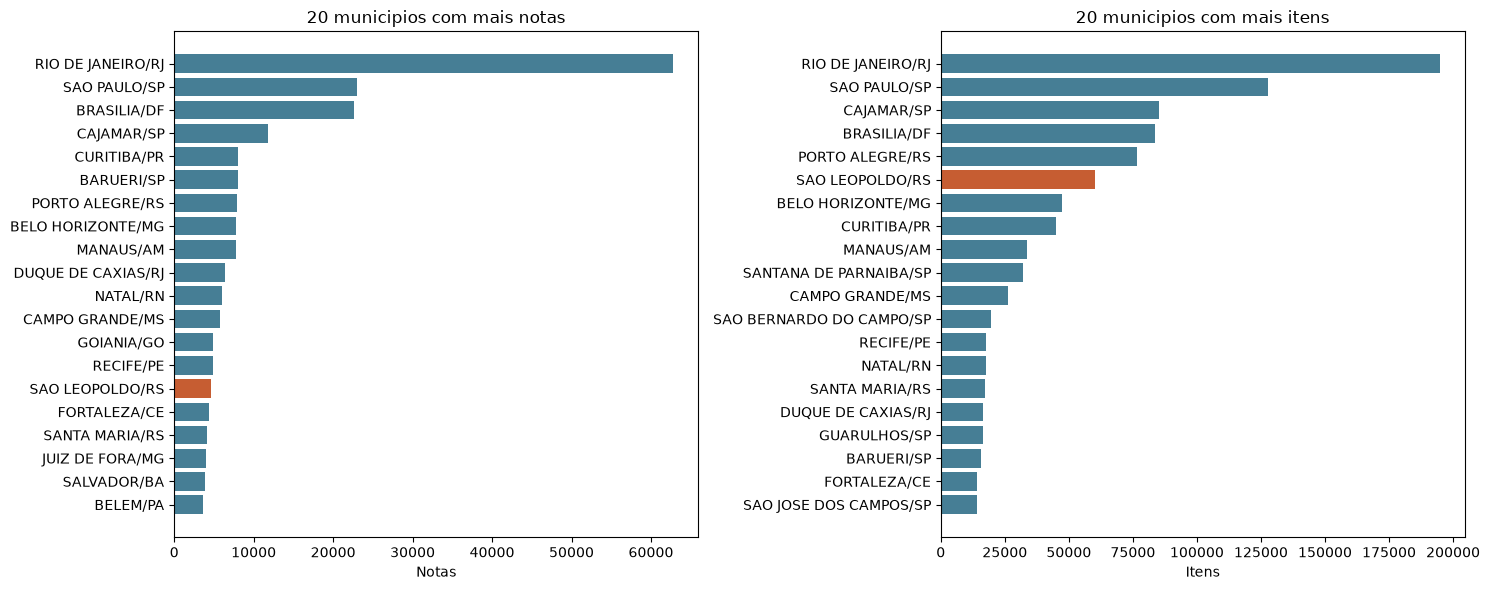

In [3]:
ranking = notes.groupby(["cidade", "uf"]).agg(notas=("chave", "size"), itens=("itens", "sum"), emitentes=("emitente", "nunique"))
ranking["linhas"] = raw.groupby(["cidade", "uf"]).size()
ranking["itens_por_nota"] = ranking["itens"] / ranking["notas"]
for metric in ["notas", "itens", "linhas"]:
    ranking[f"rank_{metric}"] = ranking[metric].rank(method="min", ascending=False).astype(int)
    ranking[f"pct_{metric}"] = 100 * ranking[metric] / ranking[metric].sum()
display(ranking.sort_values("itens", ascending=False).head(20).round(2))
display(ranking.loc[[(CITY, STATE)]].round(2))
display(notes.groupby("alvo")["itens"].describe(percentiles=[.5, .9, .99]).rename(index={False: "Outras cidades", True: "Sao Leopoldo"}))
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, metric in zip(axes, ["notas", "itens"]):
    top = ranking.nlargest(20, metric).sort_values(metric)
    labels = [f"{city}/{uf}" for city, uf in top.index]
    ax.barh(labels, top[metric], color=["#c65d32" if i == (CITY, STATE) else "#467e95" for i in top.index])
    ax.set_title(f"20 municipios com mais {metric}")
    ax.set_xlabel(metric.capitalize())
fig.tight_layout()
plt.show()

## 3. Concentracao por emitente e analise de sensibilidade

Agrupamos pelo identificador do emitente, mantendo a razao social apenas como rotulo. Retirar o maior emitente e uma analise descritiva de sensibilidade, nao uma simulacao causal.

In [4]:
suppliers = sl.groupby("emitente", dropna=False).agg(razao=("razao", "first"), notas=("chave", "size"), itens=("itens", "sum")).sort_values("notas", ascending=False)
suppliers["pct_notas"] = 100 * suppliers["notas"] / len(sl)
suppliers["pct_itens"] = 100 * suppliers["itens"] / len(sl_items)
suppliers["itens_por_nota"] = suppliers["itens"] / suppliers["notas"]
display(suppliers.reset_index(drop=True).head(15).round(2))
leader_id = suppliers.index[0]
leader = suppliers.iloc[0]
without = notes.loc[~(notes["alvo"] & notes["emitente"].eq(leader_id))]
sensitivity = without.groupby(["cidade", "uf"]).agg(notas=("chave", "size"), itens=("itens", "sum"))
for metric in ["notas", "itens"]:
    sensitivity[f"rank_{metric}"] = sensitivity[metric].rank(method="min", ascending=False)
display(sensitivity.loc[[(CITY, STATE)]])
rest_mean = notes.loc[~notes["alvo"], "itens"].mean()
sl_mean = sl["itens"].mean()
display(pd.Series({"itens_por_nota_SL": sl_mean, "itens_por_nota_outras_cidades": rest_mean,
                   "razao_entre_medias": sl_mean/rest_mean}).to_frame("valor"))

,razao,notas,itens,pct_notas,pct_itens,itens_por_nota
0,BRS SUPRIMENTOS CORPORATIVOS S/A,4536,59748,96.92,99.43,13.17
1,GUSEN COM DE AUTO PECAS LTDA,46,88,0.98,0.15,1.91
2,ELIZANE DA ROSA - ME,21,44,0.45,0.07,2.1
3,JAIRO ANTONIO MALLMANN CONSULTORIA ME,15,21,0.32,0.03,1.4
4,AKSO PRODUTOS ELETRONICOS LTDA,10,11,0.21,0.02,1.1
5,MACHADO & LANIUS COMERCIO E SERVICO LTDA,8,49,0.17,0.08,6.12
6,DEXON TECNOLOGIAS DIGITAIS LTDA,8,8,0.17,0.01,1.0
7,"TRANSRIO CAMINHOES,ONIBUS,MAQUINAS E MOTORES LTDA",5,31,0.11,0.05,6.2
8,STIHL FERRAMENTAS MOTORIZADAS LTDA.,4,6,0.09,0.01,1.5
9,TAURUS ARMAS S.A,4,26,0.09,0.04,6.5


,,notas,itens,rank_notas,rank_itens
cidade,uf,,,,
SAO LEOPOLDO,RS,144,341,370,433.0


,valor
itens_por_nota_SL,12.839530
itens_por_nota_outras_cidades,3.644227
razao_entre_medias,3.523252


## 4. A concentracao persiste nos meses?

Contagem unica dentro de cada competencia. Caso uma chave esteja em mais de um arquivo mensal, ela aparece em cada mes; os totais globais anteriores continuam deduplicados.

,notas_base,notas_SL,notas_lider,pct_SL_base,pct_lider_SL,itens_SL
mes,,,,,,
2025-01,108879,683,633,0.63,92.68,8665
2025-02,118190,1345,1319,1.14,98.07,17995
2025-03,116813,1307,1273,1.12,97.4,17014
2025-04,128641,1345,1311,1.05,97.47,16415


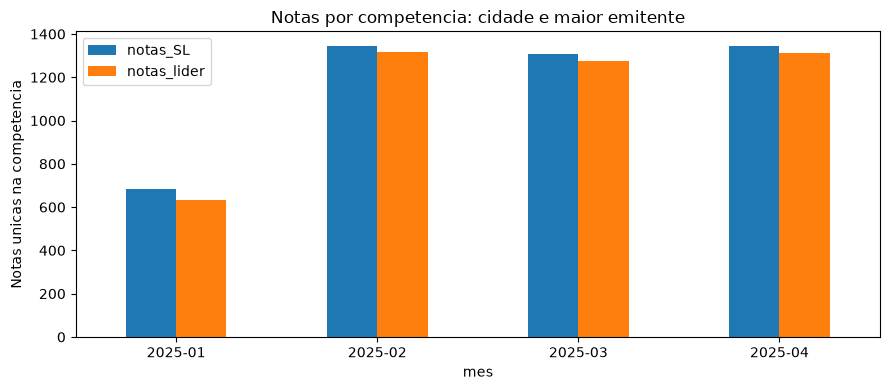

In [5]:
monthly_notes = valid.drop_duplicates(["mes", "chave"]).copy()
monthly_notes["lider"] = monthly_notes["alvo"] & monthly_notes["emitente"].eq(leader_id)
monthly = monthly_notes.groupby("mes").agg(notas_base=("chave", "size"), notas_SL=("alvo", "sum"), notas_lider=("lider", "sum"))
monthly["pct_SL_base"] = 100 * monthly["notas_SL"] / monthly["notas_base"]
monthly["pct_lider_SL"] = 100 * monthly["notas_lider"] / monthly["notas_SL"]
monthly["itens_SL"] = item_rows.loc[item_rows["alvo"]].drop_duplicates(["mes", "chave", "item"]).groupby("mes").size()
display(monthly.round(2))
monthly[["notas_SL", "notas_lider"]].plot.bar(figsize=(9, 4), title="Notas por competencia: cidade e maior emitente", rot=0)
plt.ylabel("Notas unicas na competencia")
plt.tight_layout()
plt.show()

## 5. Perfil das operacoes, destinatarios e produtos

Distribuicoes fiscais sao calculadas por nota unica. Produtos e CFOP sao calculados por item unico. O indicador consumidor final, isoladamente, nao demonstra compra de varejo presencial nem consumo de familias.

In [6]:
for col in ["modelo", "presenca", "consumidor", "natureza", "orgao", "uf_destino"]:
    comparison = pd.concat({"SL": sl[col].fillna("SEM INFORMACAO").value_counts(normalize=True)*100,
                            "Outras cidades": notes.loc[~notes["alvo"], col].fillna("SEM INFORMACAO").value_counts(normalize=True)*100}, axis=1).fillna(0)
    display(Markdown(f"**{col}: percentual de notas**"))
    display(comparison.sort_values("SL", ascending=False).head(12).round(2))
display(sl["destinatario"].value_counts().head(15).to_frame("notas"))
display(sl_items["descricao"].value_counts().head(20).to_frame("itens"))
display(sl_items["cfop"].value_counts(dropna=False).head(10).to_frame("itens"))
known_destination = sl["uf_destino"].astype("string").str.fullmatch("[A-Z]{2}").fillna(False)
other_state = sl.loc[known_destination, "uf_destino"].ne(STATE).mean()*100
print(f"Notas com UF de destino conhecida: {known_destination.sum():,}/{len(sl):,}")
print(f"Destino fora do RS entre UFs conhecidas: {other_state:.2f}%")

**modelo: percentual de notas**

,SL,Outras cidades
modelo,,
55 - NF-E EMITIDA EM SUBSTITUIÇÃO AO MODELO 1 OU 1A,100.0,100.0


**presenca: percentual de notas**

,SL,Outras cidades
presenca,,
"9 - OPERAÇÃO NÃO PRESENCIAL, OUTROS",97.20,29.80
1 - OPERAÇÃO PRESENCIAL,2.14,29.76
0 - NÃO SE APLICA,0.62,34.04
"2 - OPERAÇÃO NÃO PRESENCIAL, PELA INTERNET",0.04,3.38
"3 - OPERAÇÃO NÃO PRESENCIAL, TELEATENDIMENTO",0.00,2.36
5 - NÃO INFORMADO,0.00,0.66


**consumidor: percentual de notas**

...

,SL,Outras cidades
uf_destino,,
DF,22.41,13.20
RS,16.41,10.46
MT,7.33,2.46
SC,6.26,3.02
RR,4.55,0.88
PR,4.32,4.41
SP,3.80,7.38
PA,3.53,5.54
MS,3.48,2.51


,notas
destinatario,
INSTITUTO CHICO MENDES DE CONSERVAC DA BIODIVERSIDADE,695
INSTITUTO NACIONAL DO SEGURO SOCIAL,315
INSTITUTO FEDERAL DE EDUCACAO CIENC TECNOLOGIA DE MATO GROSS,181
INSTITUTO CHICO MENDES DE CONSERVACAO DA BIODIVERSIDADE,173
SECRETARIA EXECUTIVA/OPERACAO ACOLHIDA,162
MUNICIPIO DE CAMPOS SALES,145
MINISTERIO DA FAZENDA,126
MINISTERIO DA ECONOMIA,114
FUNDACAO UNIVERSIDADE FEDERAL DO MATO GROSSO,84


,itens
descricao,
Papel A4 BR Go Office 75g 500fl CertFSCMisto70% CU COC855709,1947
Caneta Esferografica Compactor Economic 1.0mm Azul,1388
Caneta Marca Texto Go Office Amarela,1001
Pilha Alcalina Go Tech AAA LR03 Palito 2UN,986
Fita Adesiva Sooper Transparente 48mmx50m,975
Caneta Esferografica Compactor Economic 1.0mm Preta,957
Tesoura Go Office 21cm Uso Geral,908
Pilha Alcalina Go Tech AA LR6 Pequena 2UN,794
Caneta Marca Texto Go Office Verde,669


,itens
cfop,
6949.0,53226
5949.0,6128
2202.0,304
5102.0,205
6102.0,62
1202.0,54
6108.0,30
6910.0,27
5929.0,9


Notas com UF de destino conhecida: 4,680/4,680
Destino fora do RS entre UFs conhecidas: 83.59%


## 6. Comparacao financeira: valor total dos itens por cidade

Somamos **VALOR TOTAL** dos itens unicos (chave de acesso + numero do produto), por municipio e UF do emitente. Este campo ja incorpora a quantidade: nao multiplicamos pelo campo QUANTIDADE, nem somamos VALOR NOTA FISCAL repetido nos itens.

A conversao do formato brasileiro e validada e a soma e feita em **centavos inteiros**, evitando erros de ponto flutuante. Valores ausentes ficam ausentes, com cobertura explicita; municipios sem valor observado nao recebem total zero. O ranking considera apenas os valores observados.

Os valores sao nominais, no periodo carregado, e incluem as naturezas de operacao presentes na base, inclusive eventuais remessas e devolucoes. Portanto, representam **valor dos itens registrados**, nao receita liquida, pagamentos realizados ou consumo dos moradores. Notas sem itens nao contribuem para a soma; a cobertura por cidade permite identificar essa limitacao.

,quantidade
itens_brutos_sem_valor,0
itens_brutos_com_formato_invalido,0


**20 cidades com maior valor total dos itens (R$)**

,,rank_valor,valor_total_R$,pct_valor_base,rank_itens,pct_itens,valor_medio_item_R$,cobertura_itens_pct,cobertura_notas_pct
cidade,uf,,,,,,,,
RIO DE JANEIRO,RJ,1,5155767422.42,19.06,1,11.03,26474.18,100.0,99.02
SAO PAULO,SP,2,3878198492.1,14.33,2,7.23,30392.69,100.0,99.1
APARECIDA DE GOIANIA,GO,3,2520513134.23,9.32,60,0.20,703857.34,100.0,99.44
GOIANIA,GO,4,1368493394.0,5.06,21,0.75,102917.45,100.0,99.15
POUSO ALEGRE,MG,5,774938316.35,2.86,69,0.18,247663.25,100.0,99.26
EXTREMA,MG,6,706053179.97,2.61,222,0.05,872748.06,100.0,99.16
SAO JOSE DOS PINHAIS,PR,7,644889267.61,2.38,76,0.16,229090.33,100.0,99.45
VALINHOS,SP,8,629235928.36,2.33,286,0.03,1077458.78,100.0,97.22
EMBU DAS ARTES,SP,9,588925421.51,2.18,197,0.06,604026.07,100.0,98.8


**Sao Leopoldo/RS**

,,rank_valor,valor_total_R$,pct_valor_base,rank_itens,pct_itens,valor_medio_item_R$,cobertura_itens_pct,cobertura_notas_pct
cidade,uf,,,,,,,,
SAO LEOPOLDO,RS,108,12079050.11,0.04,6,3.4,201.02,100.0,99.72


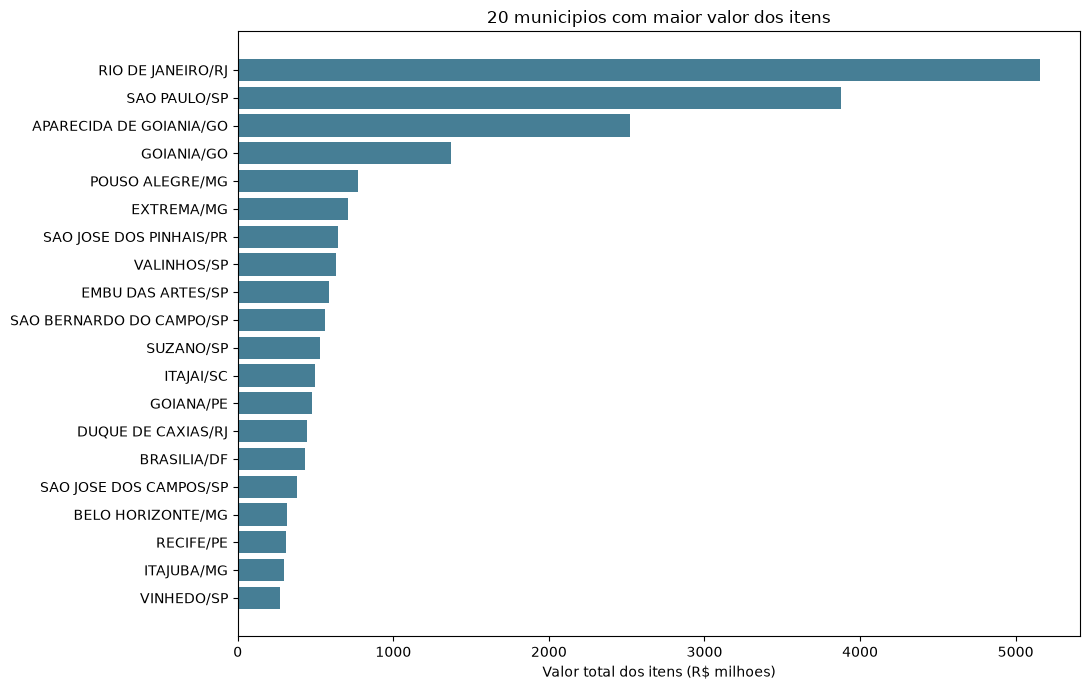

**Emitentes de Sao Leopoldo por valor dos itens**

,razao,valor_total_R$,pct_valor_SL
0,BRS SUPRIMENTOS CORPORATIVOS S/A,11240602.46,93.06
1,DEXON TECNOLOGIAS DIGITAIS LTDA,353900.0,2.93
2,STIHL FERRAMENTAS MOTORIZADAS LTDA.,99657.42,0.83
3,TAURUS ARMAS S.A,83117.75,0.69
4,JAIRO ANTONIO MALLMANN CONSULTORIA ME,56649.68,0.47
5,ELIZANE DA ROSA - ME,45794.6,0.38
6,GUSEN COM DE AUTO PECAS LTDA,45488.02,0.38
7,AKSO PRODUTOS ELETRONICOS LTDA,43323.78,0.36
8,DELTA COLOR IND E COM DE EQUIPAMENTOS ELETRONICOS LTDA,26800.0,0.22
9,MACHADO & LANIUS COMERCIO E SERVICO LTDA,22705.18,0.19



**Leitura financeira:** a base soma **R$ 27.055.115.999,63** em itens observados.
Sao Leopoldo soma **R$ 12.079.050,11**, ou **0.04%** do valor da base,
ocupando a **108a posicao em valor**, frente a 6a em itens.
O valor medio por item e **R$ 201,02**; nao se trata de preco unitario, pois cada linha pode ter varias unidades.
O maior emitente em quantidade de notas (BRS SUPRIMENTOS CORPORATIVOS S/A) representa **93.06%** do valor da cidade.
Cobertura de Sao Leopoldo: **100.00% dos itens** e **99.72% das notas** possuem algum valor de item observado.


In [7]:
# Validar valores antes da deduplicacao, para nao ocultar divergencias monetarias.
amount_text = item_rows["valor_total_item"].astype("string").str.strip().replace("", pd.NA)
valid_format = amount_text.str.fullmatch(r"-?(?:\d+|\d{1,3}(?:\.\d{3})+),\d{2}").fillna(False)
invalid_amounts = amount_text.notna() & ~valid_format
display(pd.Series({"itens_brutos_sem_valor": amount_text.isna().sum(),
                   "itens_brutos_com_formato_invalido": invalid_amounts.sum()}).to_frame("quantidade"))
assert not invalid_amounts.any(), "Revisar formatos monetarios invalidos antes de somar."
amount_cents = amount_text.str.replace(".", "", regex=False).str.replace(",", "", regex=False).astype("Int64")
amount_rows = item_rows[["chave", "item"]].assign(centavos=amount_cents)
amount_groups = amount_rows.groupby(["chave", "item"])["centavos"]
assert not amount_groups.nunique(dropna=False).gt(1).any(), "Valores divergentes para o mesmo item."
financial_items = items.copy()
financial_items["centavos"] = amount_cents.reindex(financial_items.index)

financial = financial_items.groupby(["cidade", "uf"]).agg(
    total_centavos=("centavos", lambda s: s.sum(min_count=1)),
    itens_com_valor=("centavos", "count"),
)
financial = ranking[["notas", "itens", "rank_notas", "rank_itens", "pct_itens"]].join(financial)
financial["itens_com_valor"] = financial["itens_com_valor"].fillna(0).astype(int)
financial["notas_com_valor"] = financial_items.loc[financial_items["centavos"].notna()].groupby(["cidade", "uf"])["chave"].nunique().reindex(financial.index, fill_value=0)
financial["cobertura_itens_pct"] = 100 * financial["itens_com_valor"] / financial["itens"].replace(0, float("nan"))
financial["cobertura_notas_pct"] = 100 * financial["notas_com_valor"] / financial["notas"]
financial["valor_total_R$"] = financial["total_centavos"] / 100
financial["valor_medio_item_R$"] = financial["valor_total_R$"] / financial["itens_com_valor"].replace(0, float("nan"))
base_cents = financial_items["centavos"].sum(min_count=1)
assert pd.notna(base_cents) and base_cents > 0
assert financial["total_centavos"].sum() == base_cents, "Soma municipal nao reconcilia com a base."
financial["pct_valor_base"] = 100 * financial["total_centavos"] / base_cents
financial["rank_valor"] = financial["total_centavos"].rank(method="min", ascending=False).astype("Int64")
financial = financial.sort_values("total_centavos", ascending=False)
view_cols = ["rank_valor", "valor_total_R$", "pct_valor_base", "rank_itens", "pct_itens", "valor_medio_item_R$", "cobertura_itens_pct", "cobertura_notas_pct"]
display(Markdown("**20 cidades com maior valor total dos itens (R$)**"))
display(financial[view_cols].head(20).round(2))
display(Markdown("**Sao Leopoldo/RS**"))
display(financial.loc[[(CITY, STATE)], view_cols].round(2))

fig, ax = plt.subplots(figsize=(11, 7))
financial_top = financial.head(20).sort_values("total_centavos")
ax.barh([f"{city}/{uf}" for city, uf in financial_top.index],
        (financial_top["valor_total_R$"] / 1_000_000).astype(float),
        color=["#c65d32" if i == (CITY, STATE) else "#467e95" for i in financial_top.index])
ax.set_title("20 municipios com maior valor dos itens")
ax.set_xlabel("Valor total dos itens (R$ milhoes)")
fig.tight_layout()
plt.show()

sl_financial = financial_items.loc[financial_items["alvo"]]
supplier_values = sl_financial.groupby("emitente", dropna=False).agg(
    razao=("razao", "first"), total_centavos=("centavos", lambda s: s.sum(min_count=1)))
sl_cents = sl_financial["centavos"].sum(min_count=1)
assert pd.notna(sl_cents) and sl_cents > 0
supplier_values["valor_total_R$"] = supplier_values["total_centavos"] / 100
supplier_values["pct_valor_SL"] = 100 * supplier_values["total_centavos"] / sl_cents
display(Markdown("**Emitentes de Sao Leopoldo por valor dos itens**"))
display(supplier_values.sort_values("total_centavos", ascending=False)[["razao", "valor_total_R$", "pct_valor_SL"]].reset_index(drop=True).head(10).round(2))
fsl = financial.loc[(CITY, STATE)]
leader_value_pct = supplier_values.loc[leader_id, "pct_valor_SL"]

def brl(value):
    return "R$ " + f"{value:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

display(Markdown(f"""
**Leitura financeira:** a base soma **{brl(base_cents / 100)}** em itens observados.
Sao Leopoldo soma **{brl(sl_cents / 100)}**, ou **{fsl['pct_valor_base']:.2f}%** do valor da base,
ocupando a **{int(fsl['rank_valor'])}a posicao em valor**, frente a {int(fsl['rank_itens'])}a em itens.
O valor medio por item e **{brl(fsl['valor_medio_item_R$'])}**; nao se trata de preco unitario, pois cada linha pode ter varias unidades.
O maior emitente em quantidade de notas ({leader['razao']}) representa **{leader_value_pct:.2f}%** do valor da cidade.
Cobertura de Sao Leopoldo: **{fsl['cobertura_itens_pct']:.2f}% dos itens** e **{fsl['cobertura_notas_pct']:.2f}% das notas** possuem algum valor de item observado.
"""))

## 7. Sintese calculada e limites

As evidencias permitem explicar a composicao deste dataset. Nao identificam por si so contratos, centros de distribuicao, participacao no mercado nacional ou razoes comerciais da localizacao do fornecedor. Confirmar essas causas exigiria outras fontes.

In [8]:
r = ranking.loc[(CITY, STATE)]
display(Markdown(f"""
- **Escopo:** {FILES[0].stem} a {FILES[-1].stem}, {len(FILES)} arquivos mensais, {len(notes):,} notas unicas na base.
- **Sao Leopoldo/RS:** {len(sl):,} notas ({r['pct_notas']:.2f}% da base), {len(sl_items):,} itens ({r['pct_itens']:.2f}%). Posicao {int(r['rank_notas'])} em notas e {int(r['rank_itens'])} em itens.
- **Principal concentracao:** {leader['razao']} responde por {int(leader['notas']):,} notas ({leader['pct_notas']:.2f}% da cidade) e {int(leader['itens']):,} itens ({leader['pct_itens']:.2f}%). Sem esse emitente restam {len(sl)-int(leader['notas']):,} notas.
- **Amplificacao por itens:** {sl_mean:.2f} itens por nota na cidade versus {rest_mean:.2f} nas outras cidades ({sl_mean/rest_mean:.2f} vezes).
- **Valor dos itens:** {brl(sl_cents / 100)} em Sao Leopoldo ({fsl["pct_valor_base"]:.2f}% da base), posicao {int(fsl["rank_valor"])} em valor; {leader_value_pct:.2f}% desse valor pertence ao maior emitente em notas.
- **Geografia:** {other_state:.2f}% das notas com UF de destino conhecida destinam-se a fora do RS. Municipio do emitente nao equivale a municipio do consumidor.

**Interpretacao:** a concentracao em um fornecedor, combinada ao numero de itens por nota, explica o destaque da cidade neste recorte. As tabelas de destinatarios, produtos e presenca permitem caracterizar o perfil das operacoes. A concatenacao de cabecalhos e itens aumenta a contagem de linhas e deve ser separada da contagem de notas.

**Implicacao para o classificador:** frequencia de descricoes pode refletir o mix de um fornecedor institucional. Compare os filtros de consumidor final e presenca do comprador antes de tratar esta base como representativa do varejo de consumo. Este notebook nao modifica dados nem aplica filtros de modelagem.
"""))


- **Escopo:** 2025-01 a 2025-04, 4 arquivos mensais, 472,523 notas unicas na base.
- **Sao Leopoldo/RS:** 4,680 notas (0.99% da base), 60,089 itens (3.40%). Posicao 15 em notas e 6 em itens.
- **Principal concentracao:** BRS SUPRIMENTOS CORPORATIVOS S/A responde por 4,536 notas (96.92% da cidade) e 59,748 itens (99.43%). Sem esse emitente restam 144 notas.
- **Amplificacao por itens:** 12.84 itens por nota na cidade versus 3.64 nas outras cidades (3.52 vezes).
- **Valor dos itens:** R$ 12.079.050,11 em Sao Leopoldo (0.04% da base), posicao 108 em valor; 93.06% desse valor pertence ao maior emitente em notas.
- **Geografia:** 83.59% das notas com UF de destino conhecida destinam-se a fora do RS. Municipio do emitente nao equivale a municipio do consumidor.

**Interpretacao:** a concentracao em um fornecedor, combinada ao numero de itens por nota, explica o destaque da cidade neste recorte. As tabelas de destinatarios, produtos e presenca permitem caracterizar o perfil das operacoes. A concatenacao de cabecalhos e itens aumenta a contagem de linhas e deve ser separada da contagem de notas.

**Implicacao para o classificador:** frequencia de descricoes pode refletir o mix de um fornecedor institucional. Compare os filtros de consumidor final e presenca do comprador antes de tratar esta base como representativa do varejo de consumo. Este notebook nao modifica dados nem aplica filtros de modelagem.
